
# Case Study 1: Chapter 8 – Stress Testing the NorthGrid–SouthGrid System

Authors: Neeraj Dhanraj Bokde (www.neerajbokde.in) and Carlo Fanara

Affiliation: Renewable & Sustainable Energy Research Center, TII, Abu Dhabi

Corresponding author: neeraj.bokde@tii.ae / neerajdhanraj@gmail.com

Description: This script implements the resilience and stress-testing case study from Chapter 8 ("Reliability and Resilience in Power Systems") of The PyPSA Handbook. It builds directly upon the optimized transmission system from Chapter 7, which models a greenfield grid with spatial separation of renewable supply (NorthGrid) and gas-backed demand (SouthGrid).

Four structured stress-testing scenarios are simulated to evaluate the robustness of the fixed-capacity system under real-world disruptions:

 - Scenario A: Transmission corridor outage (Corridor B down for 24h)
 
 - Scenario B: Wind collapse due to storm (wind drops significantly)
 
 - Scenario C: Gas outage and battery failure (planned maintenance)
 
 - Scenario D: Heatwave with elevated demand and solar reduction

Each scenario is analyzed using LOPF under fixed capacity assumptions, and outputs include generation dispatch, transmission flows, marginal prices, and unserved energy. The results demonstrate the relative resilience and limitations of a co-optimized but fixed system.

Book Reference: Bokde, N. D., & Fanara, C. (2025). Reliability and Resilience in Power Systems. In: The PyPSA Handbook: Integrated Power System Analysis and Renewable Energy Modeling, Chapter 8. Publisher: Elsevier Science ISBN: 044326631X, 9780443266317

In [31]:
# Imports
import pypsa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Plotting style
plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 14,
    "axes.labelsize": 14,
    "legend.fontsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12
})

### Shared Inputs for All Scenarios

In [32]:
# Time series: 168 hours (1 week)
snapshots = pd.date_range("2025-01-01", periods=168, freq="h")

# Demand profile: sinusoidal daily + weekly fluctuation
load_profile = pd.Series(300 + 60 * np.sin(np.linspace(0, 3*np.pi, 168)), index=snapshots)

# Wind and solar profiles (with slight variation)
np.random.seed(0)
wind_profile = pd.Series(np.clip(np.random.normal(0.6, 0.2, 168), 0, 1), index=snapshots)
wind_profile[60:70] = 0.2  # wind lull for realism
solar_profile = pd.Series(np.maximum(0, np.sin(np.linspace(0, 7*np.pi, 168))), index=snapshots)

# Storm case (Scenario B)
wind_storm = wind_profile.copy()
wind_storm[60:100] *= 0.3  # storm reduces wind generation

# Gas outage (Scenarios A & C)
gas_availability = pd.Series(1.0, index=snapshots)
gas_availability[40:60] = 0.0  # maintenance period

# Corridor outage profile (Scenario A)
corridor_b_outage = pd.Series(1.0, index=snapshots)
corridor_b_outage[72:96] = 0.0  # simulated outage

# Synthetic coordinates for plotting/network structure
bus_coords = {
    "NorthWind": (10.0, 56.0),
    "NorthSolar": (11.0, 56.1),
    "NorthStorage": (10.5, 55.8),
    "NorthHub": (10.5, 55.5),
    "SouthHub": (10.5, 54.5),
    "SouthLoad": (10.3, 54.2),
    "SouthBackupGen": (10.7, 54.1)
}

# Internal high-capacity links (within regions)
internal_links = [
    ("NorthWind", "NorthHub"),
    ("NorthSolar", "NorthHub"),
    ("NorthStorage", "NorthHub"),
    ("SouthBackupGen", "SouthHub"),
    ("SouthHub", "SouthLoad")
]



### Scenario A: Corridor B Outage (Hours 72–96)

In [33]:
# Create a new PyPSA network for Scenario A
network_a = pypsa.Network()
network_a.set_snapshots(snapshots)

# Add all buses with predefined coordinates
for bus, (x, y) in bus_coords.items():
    network_a.add("Bus", bus, x=x, y=y)

# Add load profile to SouthLoad bus
network_a.add("Load", "SouthDemand", bus="SouthLoad", p_set=load_profile)

# Add fixed renewable generators
network_a.add("Generator", "WindNorth", bus="NorthWind", p_nom=670,
              p_nom_extendable=False, p_max_pu=wind_profile, marginal_cost=0)
network_a.add("Generator", "SolarNorth", bus="NorthSolar", p_nom=205,
              p_nom_extendable=False, p_max_pu=solar_profile, marginal_cost=0)

# Add gas generator with outage profile
network_a.add("Generator", "GasSouth", bus="SouthBackupGen", p_nom=220,
              p_nom_extendable=False, p_max_pu=gas_availability,
              marginal_cost=70, carrier="gas")

# Add dummy generator to simulate unserved energy if demand cannot be met
network_a.add("Generator", "Unserved", bus="SouthLoad", p_nom_extendable=True,
              capital_cost=0, marginal_cost=1000, carrier="load_shed")

# Add a battery unit (disabled in this scenario)
network_a.add("StorageUnit", "Battery_North", bus="NorthStorage", p_nom=0,
              p_nom_extendable=False, max_hours=4, efficiency_store=0.9,
              efficiency_dispatch=0.9, capital_cost=200, marginal_cost=0.01)

# Add internal transmission links within each grid
for a, b in internal_links:
    network_a.add("Link", f"{a}_to_{b}", bus0=a, bus1=b,
                  p_nom=1000, efficiency=1.0)

# Add inter-regional corridors (Corridor B has forced outage via p_max_pu)
network_a.add("Link", "Corridor_A", bus0="NorthHub", bus1="SouthHub",
              p_nom=0, p_nom_extendable=False, efficiency=1.0, carrier="AC")
network_a.add("Link", "Corridor_B", bus0="NorthHub", bus1="SouthHub",
              p_nom=360, p_nom_extendable=False, efficiency=1.0,
              p_max_pu=corridor_b_outage, carrier="AC")

# Add CO2 emissions constraint for gas-based generation
network_a.add("Carrier", "gas", co2_emissions=0.2)
network_a.add("GlobalConstraint", "co2_limit",
              type="primary_energy_cap", carrier_attribute="co2_emissions",
              sense="<=", constant=10000)

# Solve the optimization problem using GLPK solver
network_a.optimize(solver_name="highs")



Index(['NorthWind', 'NorthSolar', 'NorthStorage', 'NorthHub', 'SouthHub',
       'SouthLoad', 'SouthBackupGen'],
      dtype='str', name='name')
Index(['Unserved'], dtype='str', name='name')
Index(['NorthWind_to_NorthHub', 'NorthSolar_to_NorthHub',
       'NorthStorage_to_NorthHub', 'SouthBackupGen_to_SouthHub',
       'SouthHub_to_SouthLoad', 'Corridor_A', 'Corridor_B'],
      dtype='str', name='name')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io: Writing time: 0.07s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 2353 primals, 6049 duals
Objective: 1.67e+06
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Link-fix-p-lower, Link-fix-p-upper, StorageUnit-fix-p_dispatch-lower, StorageUnit-fix-p_dispatch-upper, StorageUnit-fix-p_store-lower, StorageUnit-f

('ok', 'optimal')

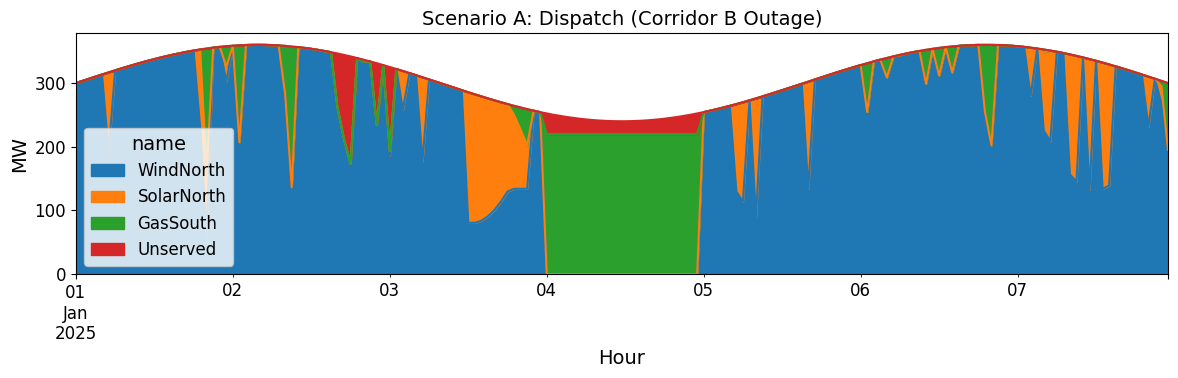

In [34]:
# Plot generation dispatch over time
network_a.generators_t.p.plot.area(title="Scenario A: Dispatch (Corridor B Outage)", figsize=(12, 4))
plt.ylabel("MW"); plt.xlabel("Hour"); plt.tight_layout(); plt.show()

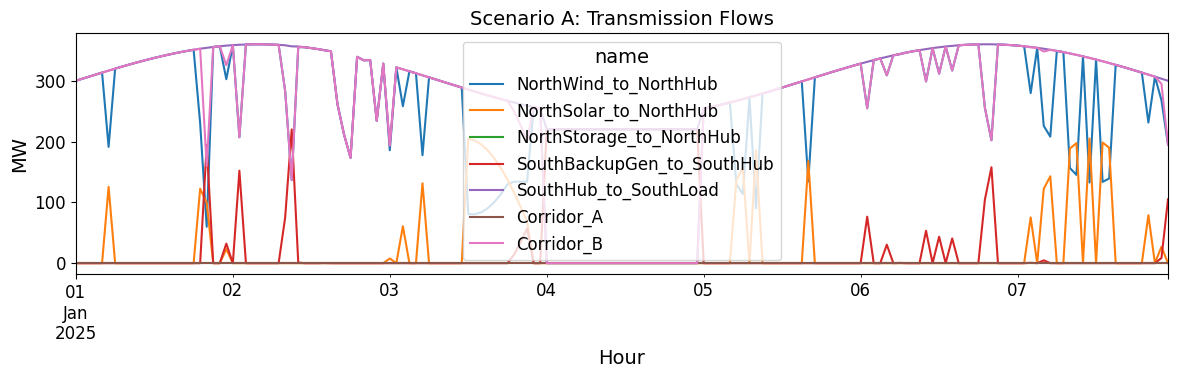

In [35]:
# Plot power flows across the transmission links
network_a.links_t.p0.plot(title="Scenario A: Transmission Flows", figsize=(12, 4))
plt.ylabel("MW"); plt.xlabel("Hour"); plt.tight_layout(); plt.show()

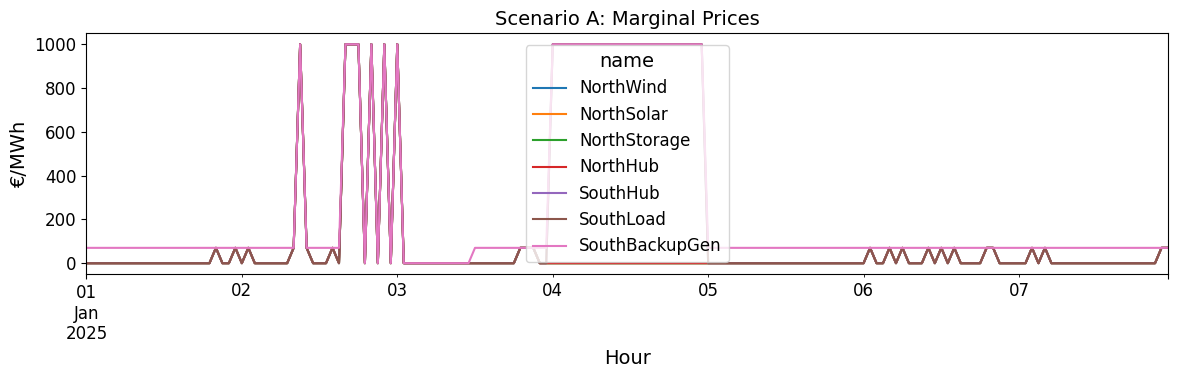

In [36]:
# Plot marginal prices at each bus
network_a.buses_t.marginal_price.plot(title="Scenario A: Marginal Prices", figsize=(12, 4))
plt.ylabel("€/MWh"); plt.xlabel("Hour"); plt.tight_layout(); plt.show()

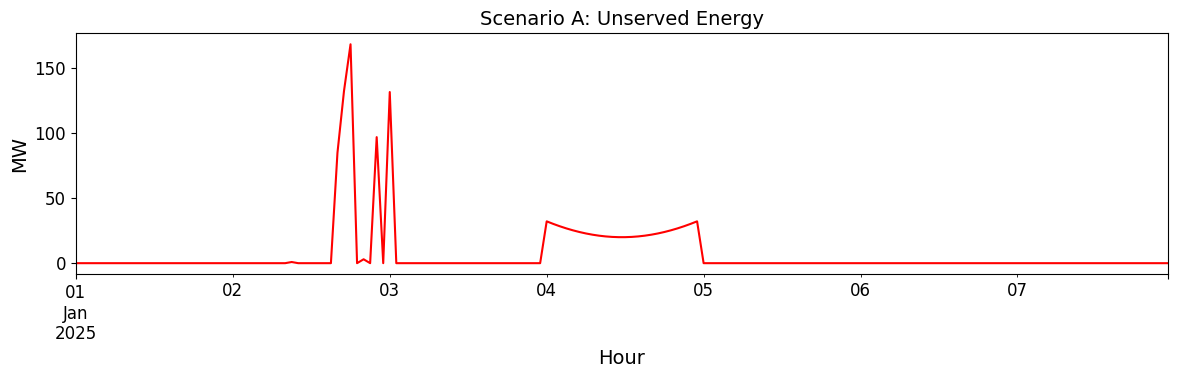

In [37]:
# Plot unserved energy to indicate supply shortage
network_a.generators_t.p["Unserved"].plot(title="Scenario A: Unserved Energy", figsize=(12, 4), color='red')
plt.ylabel("MW"); plt.xlabel("Hour"); plt.tight_layout(); plt.show()

### Scenario B: Wind Collapse Due to Storm (Hours 60–100)

In [38]:
# Create a new network for Scenario B
network_b = pypsa.Network()
network_b.set_snapshots(snapshots)

# Add all buses to the network
for bus, (x, y) in bus_coords.items():
    network_b.add("Bus", bus, x=x, y=y)

# Add load profile to SouthLoad bus
network_b.add("Load", "SouthDemand", bus="SouthLoad", p_set=load_profile)

# Add wind generator with reduced output due to storm between 60–100h
network_b.add("Generator", "WindNorth", bus="NorthWind", p_nom=670,
              p_nom_extendable=False, p_max_pu=wind_storm, marginal_cost=0)

# Add solar generator (normal operation)
network_b.add("Generator", "SolarNorth", bus="NorthSolar", p_nom=205,
              p_nom_extendable=False, p_max_pu=solar_profile, marginal_cost=0)

# Gas generator is fully operational in this scenario
network_b.add("Generator", "GasSouth", bus="SouthBackupGen", p_nom=220,
              p_nom_extendable=False, p_max_pu=1.0, marginal_cost=70, carrier="gas")

# Dummy generator to simulate unserved demand
network_b.add("Generator", "Unserved", bus="SouthLoad", p_nom_extendable=True,
              capital_cost=0, marginal_cost=1000, carrier="load_shed")

# Battery storage is disabled in this test
network_b.add("StorageUnit", "Battery_North", bus="NorthStorage", p_nom=0,
              p_nom_extendable=False, max_hours=4, efficiency_store=0.9,
              efficiency_dispatch=0.9, capital_cost=200, marginal_cost=0.01)

# Add internal high-capacity links (non-restrictive)
for a, b in internal_links:
    network_b.add("Link", f"{a}_to_{b}", bus0=a, bus1=b,
                  p_nom=1000, efficiency=1.0)

# Use optimized transmission corridors from Chapter 7
network_b.add("Link", "Corridor_A", bus0="NorthHub", bus1="SouthHub",
              p_nom=0, p_nom_extendable=False, efficiency=1.0, carrier="AC")
network_b.add("Link", "Corridor_B", bus0="NorthHub", bus1="SouthHub",
              p_nom=360, p_nom_extendable=False, efficiency=1.0, carrier="AC")

# Emissions constraint for CO2 from gas-based generation
network_b.add("Carrier", "gas", co2_emissions=0.2)
network_b.add("GlobalConstraint", "co2_limit",
              type="primary_energy_cap", carrier_attribute="co2_emissions",
              sense="<=", constant=10000)

# Optimize with fixed capacities under storm conditions
network_b.optimize(solver_name="highs")



Index(['NorthWind', 'NorthSolar', 'NorthStorage', 'NorthHub', 'SouthHub',
       'SouthLoad', 'SouthBackupGen'],
      dtype='str', name='name')
Index(['Unserved'], dtype='str', name='name')
Index(['NorthWind_to_NorthHub', 'NorthSolar_to_NorthHub',
       'NorthStorage_to_NorthHub', 'SouthBackupGen_to_SouthHub',
       'SouthHub_to_SouthLoad', 'Corridor_A', 'Corridor_B'],
      dtype='str', name='name')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io: Writing time: 0.07s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 2353 primals, 6049 duals
Objective: 4.16e+05
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Link-fix-p-lower, Link-fix-p-upper, StorageUnit-fix-p_dispatch-lower, StorageUnit-fix-p_dispatch-upper, StorageUnit-fix-p_store-lower, StorageUnit-f

('ok', 'optimal')

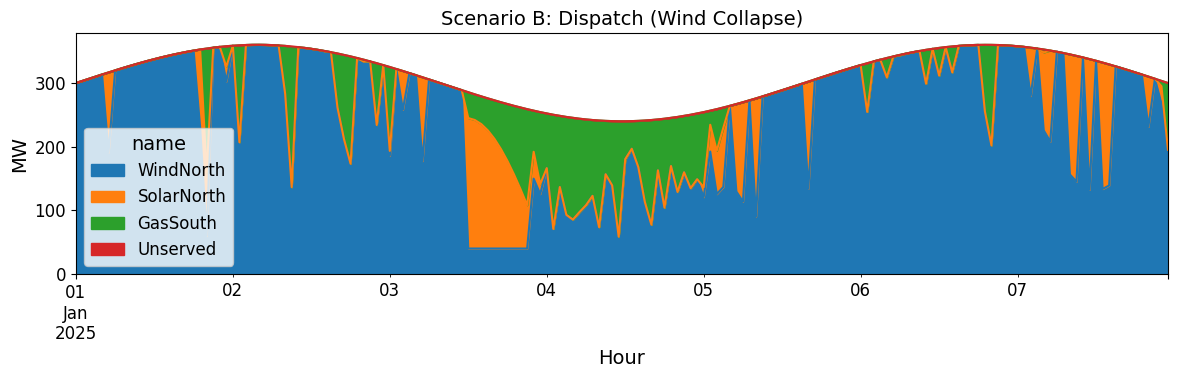

In [39]:
# Plot results
network_b.generators_t.p.plot.area(title="Scenario B: Dispatch (Wind Collapse)", figsize=(12, 4))
plt.ylabel("MW"); plt.xlabel("Hour"); plt.tight_layout(); plt.show()

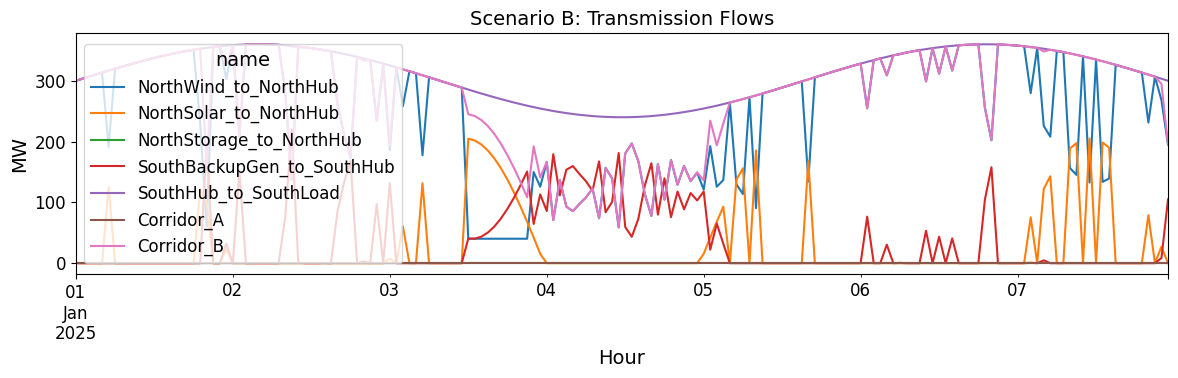

In [40]:
network_b.links_t.p0.plot(title="Scenario B: Transmission Flows", figsize=(12, 4))
plt.ylabel("MW"); plt.xlabel("Hour"); plt.tight_layout(); plt.show()

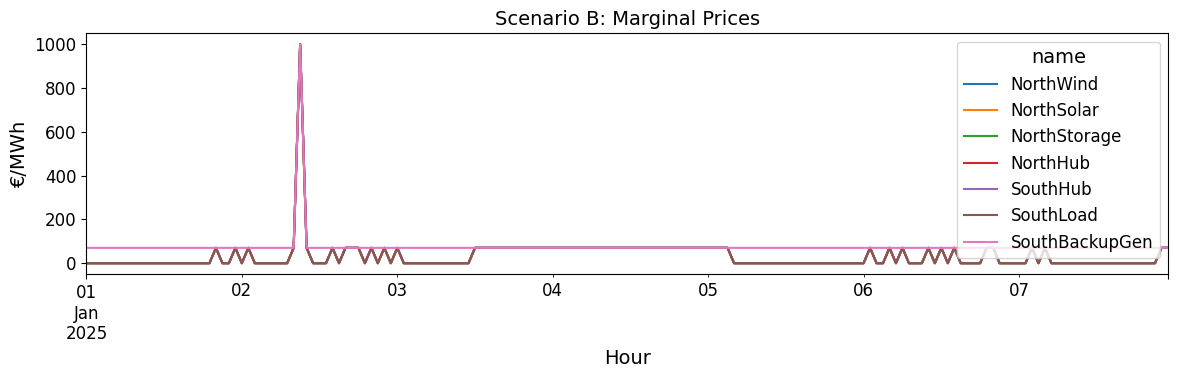

In [41]:
network_b.buses_t.marginal_price.plot(title="Scenario B: Marginal Prices", figsize=(12, 4))
plt.ylabel("€/MWh"); plt.xlabel("Hour"); plt.tight_layout(); plt.show()

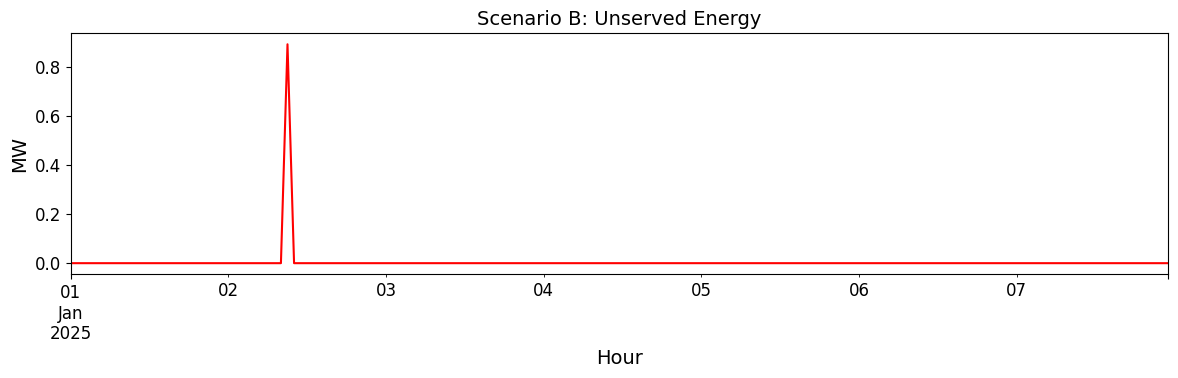

In [42]:
network_b.generators_t.p["Unserved"].plot(title="Scenario B: Unserved Energy", figsize=(12, 4), color='red')
plt.ylabel("MW"); plt.xlabel("Hour"); plt.tight_layout(); plt.show()

### Scenario C: Gas Maintenance + Battery Failure

In [43]:
# Create a new network for Scenario C
network_c = pypsa.Network()
network_c.set_snapshots(snapshots)

# Add all buses to the network
for bus, (x, y) in bus_coords.items():
    network_c.add("Bus", bus, x=x, y=y)

# Add base load to the SouthLoad bus
network_c.add("Load", "SouthDemand", bus="SouthLoad", p_set=load_profile)

# Wind and solar generators operate normally
network_c.add("Generator", "WindNorth", bus="NorthWind", p_nom=670,
              p_nom_extendable=False, p_max_pu=wind_profile, marginal_cost=0)
network_c.add("Generator", "SolarNorth", bus="NorthSolar", p_nom=205,
              p_nom_extendable=False, p_max_pu=solar_profile, marginal_cost=0)

# Gas generator with maintenance outage from 40–60h (availability = 0)
network_c.add("Generator", "GasSouth", bus="SouthBackupGen", p_nom=220,
              p_nom_extendable=False, p_max_pu=gas_availability,
              marginal_cost=70, carrier="gas")

# Dummy generator to track unserved demand
network_c.add("Generator", "Unserved", bus="SouthLoad", p_nom_extendable=True,
              capital_cost=0, marginal_cost=1000, carrier="load_shed")

# Battery is non-operational due to failure during the test horizon
network_c.add("StorageUnit", "Battery_North", bus="NorthStorage", p_nom=0,
              p_nom_extendable=False, max_hours=4, efficiency_store=0.9,
              efficiency_dispatch=0.9, capital_cost=200, marginal_cost=0.01)

# Internal links remain unconstrained
for a, b in internal_links:
    network_c.add("Link", f"{a}_to_{b}", bus0=a, bus1=b,
                  p_nom=1000, efficiency=1.0)

# Transmission corridors as previously optimized
network_c.add("Link", "Corridor_A", bus0="NorthHub", bus1="SouthHub",
              p_nom=0, p_nom_extendable=False, efficiency=1.0, carrier="AC")
network_c.add("Link", "Corridor_B", bus0="NorthHub", bus1="SouthHub",
              p_nom=360, p_nom_extendable=False, efficiency=1.0, carrier="AC")

# CO2 emissions limit to constrain gas generation
network_c.add("Carrier", "gas", co2_emissions=0.2)
network_c.add("GlobalConstraint", "co2_limit",
              type="primary_energy_cap", carrier_attribute="co2_emissions",
              sense="<=", constant=10000)

# Run optimization with GLPK under gas and storage outage
network_c.optimize(solver_name="highs")



Index(['NorthWind', 'NorthSolar', 'NorthStorage', 'NorthHub', 'SouthHub',
       'SouthLoad', 'SouthBackupGen'],
      dtype='str', name='name')
Index(['Unserved'], dtype='str', name='name')
Index(['NorthWind_to_NorthHub', 'NorthSolar_to_NorthHub',
       'NorthStorage_to_NorthHub', 'SouthBackupGen_to_SouthHub',
       'SouthHub_to_SouthLoad', 'Corridor_A', 'Corridor_B'],
      dtype='str', name='name')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io: Writing time: 0.07s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 2353 primals, 6049 duals
Objective: 7.21e+05
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Link-fix-p-lower, Link-fix-p-upper, StorageUnit-fix-p_dispatch-lower, StorageUnit-fix-p_dispatch-upper, StorageUnit-fix-p_store-lower, StorageUnit-f

('ok', 'optimal')

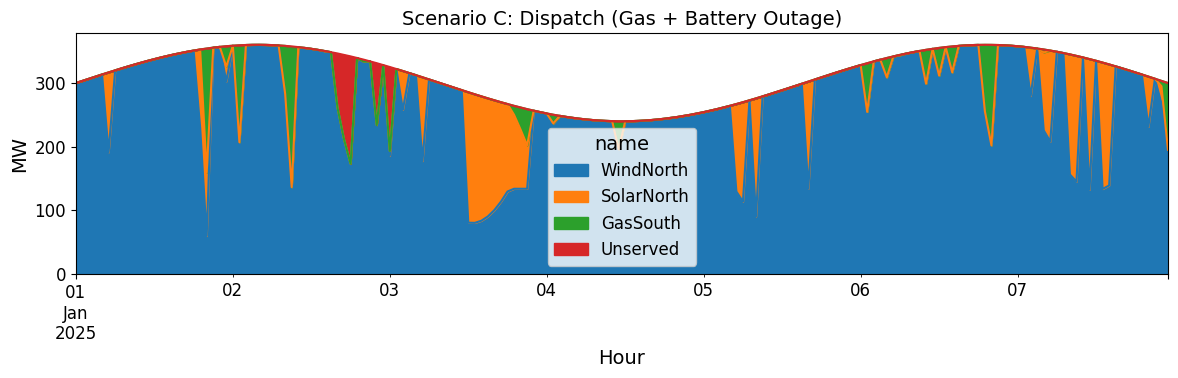

In [44]:
# Plot dispatch results
network_c.generators_t.p.plot.area(title="Scenario C: Dispatch (Gas + Battery Outage)", figsize=(12, 4))
plt.ylabel("MW"); plt.xlabel("Hour"); plt.tight_layout(); plt.show()

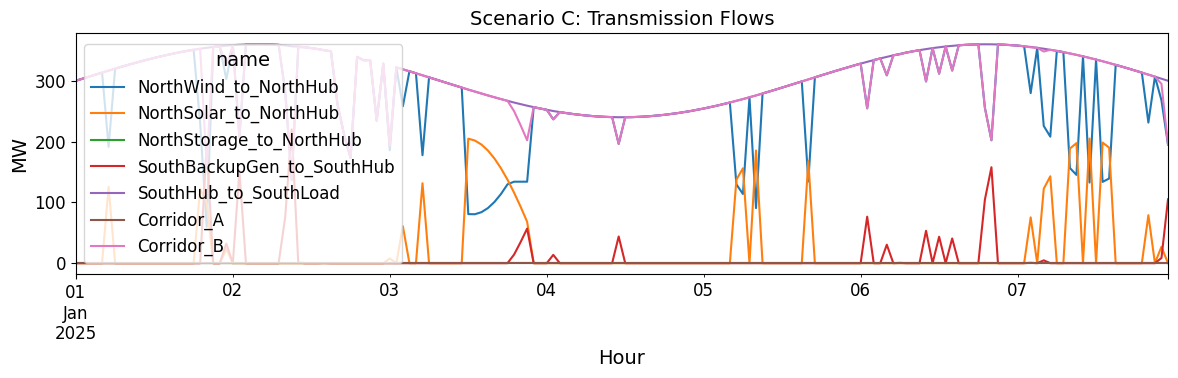

In [45]:
# Plot transmission flows
network_c.links_t.p0.plot(title="Scenario C: Transmission Flows", figsize=(12, 4))
plt.ylabel("MW"); plt.xlabel("Hour"); plt.tight_layout(); plt.show()

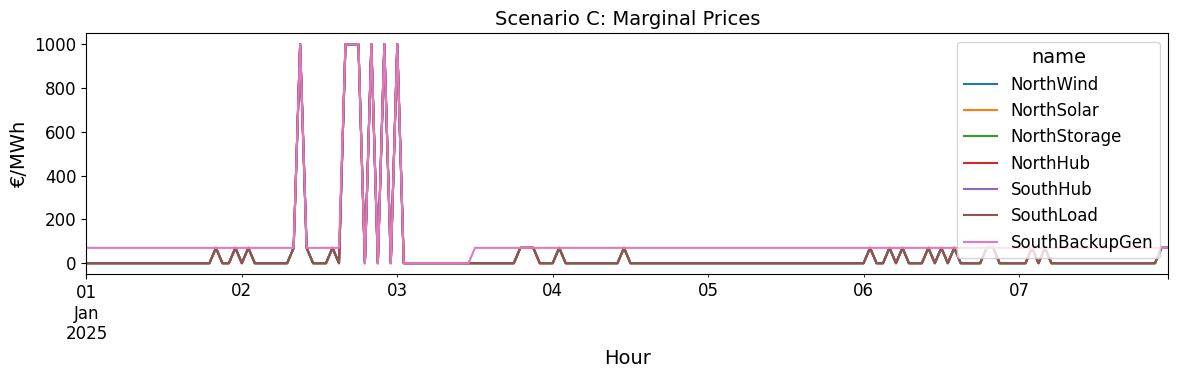

In [46]:
# Plot marginal prices
network_c.buses_t.marginal_price.plot(title="Scenario C: Marginal Prices", figsize=(12, 4))
plt.ylabel("€/MWh"); plt.xlabel("Hour"); plt.tight_layout(); plt.show()

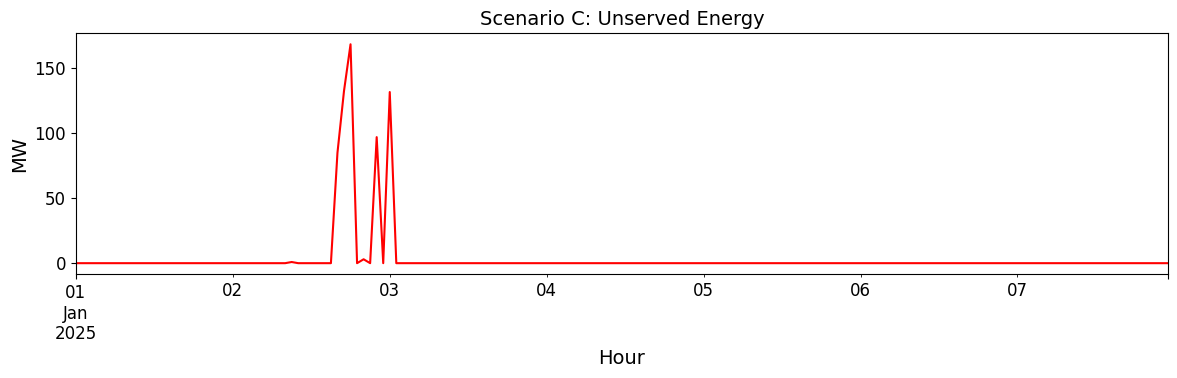

In [47]:
# Plot unserved energy output
network_c.generators_t.p["Unserved"].plot(title="Scenario C: Unserved Energy", figsize=(12, 4), color='red')
plt.ylabel("MW"); plt.xlabel("Hour"); plt.tight_layout(); plt.show()

### Scenario D: Heatwave + Solar Dip

In [48]:
# Create a new network for Scenario D
network_d = pypsa.Network()
network_d.set_snapshots(snapshots)

# Add all buses with coordinates
for bus, (x, y) in bus_coords.items():
    network_d.add("Bus", bus, x=x, y=y)

# Demand includes a heatwave-induced spike from hour 110 to 140 (already built into load_profile)
network_d.add("Load", "SouthDemand", bus="SouthLoad", p_set=load_profile)

# Wind generator operates with normal profile
network_d.add("Generator", "WindNorth", bus="NorthWind", p_nom=670,
              p_nom_extendable=False, p_max_pu=wind_profile, marginal_cost=0)

# Solar generation is reduced due to assumed cloud cover (reflected in solar_profile)
network_d.add("Generator", "SolarNorth", bus="NorthSolar", p_nom=205,
              p_nom_extendable=False, p_max_pu=solar_profile, marginal_cost=0)

# Gas generator is fully available to meet high demand
network_d.add("Generator", "GasSouth", bus="SouthBackupGen", p_nom=220,
              p_nom_extendable=False, p_max_pu=1.0, marginal_cost=70, carrier="gas")

# Dummy generator allows unmet demand to be captured as unserved energy
network_d.add("Generator", "Unserved", bus="SouthLoad", p_nom_extendable=True,
              capital_cost=0, marginal_cost=1000, carrier="load_shed")

# Battery unit is disabled to isolate the system's thermal and dispatch limits
network_d.add("StorageUnit", "Battery_North", bus="NorthStorage", p_nom=0,
              p_nom_extendable=False, max_hours=4, efficiency_store=0.9,
              efficiency_dispatch=0.9, capital_cost=200, marginal_cost=0.01)

# Add internal connections (non-limiting)
for a, b in internal_links:
    network_d.add("Link", f"{a}_to_{b}", bus0=a, bus1=b,
                  p_nom=1000, efficiency=1.0)

# Add optimized corridors
network_d.add("Link", "Corridor_A", bus0="NorthHub", bus1="SouthHub",
              p_nom=0, p_nom_extendable=False, efficiency=1.0, carrier="AC")
network_d.add("Link", "Corridor_B", bus0="NorthHub", bus1="SouthHub",
              p_nom=360, p_nom_extendable=False, efficiency=1.0, carrier="AC")

# CO2 emissions constraint remains active
network_d.add("Carrier", "gas", co2_emissions=0.2)
network_d.add("GlobalConstraint", "co2_limit",
              type="primary_energy_cap", carrier_attribute="co2_emissions",
              sense="<=", constant=10000)

# Solve the network with high load and weak solar availability
network_d.optimize(solver_name="highs")



Index(['NorthWind', 'NorthSolar', 'NorthStorage', 'NorthHub', 'SouthHub',
       'SouthLoad', 'SouthBackupGen'],
      dtype='str', name='name')
Index(['Unserved'], dtype='str', name='name')
Index(['NorthWind_to_NorthHub', 'NorthSolar_to_NorthHub',
       'NorthStorage_to_NorthHub', 'SouthBackupGen_to_SouthHub',
       'SouthHub_to_SouthLoad', 'Corridor_A', 'Corridor_B'],
      dtype='str', name='name')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io: Writing time: 0.07s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 2353 primals, 6049 duals
Objective: 1.47e+05
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Link-fix-p-lower, Link-fix-p-upper, StorageUnit-fix-p_dispatch-lower, StorageUnit-fix-p_dispatch-upper, StorageUnit-fix-p_store-lower, StorageUnit-f

('ok', 'optimal')

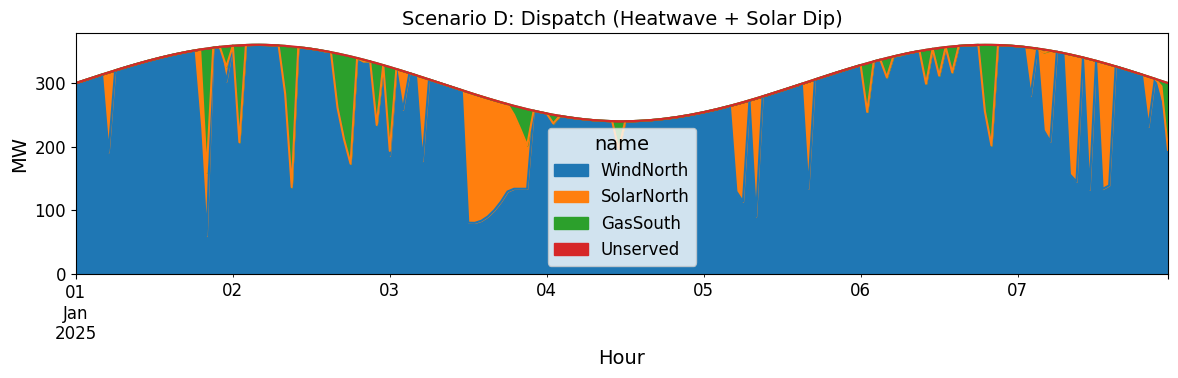

In [49]:
# Plot generation dispatch under heatwave and solar dip
network_d.generators_t.p.plot.area(title="Scenario D: Dispatch (Heatwave + Solar Dip)", figsize=(12, 4))
plt.ylabel("MW"); plt.xlabel("Hour"); plt.tight_layout(); plt.show()

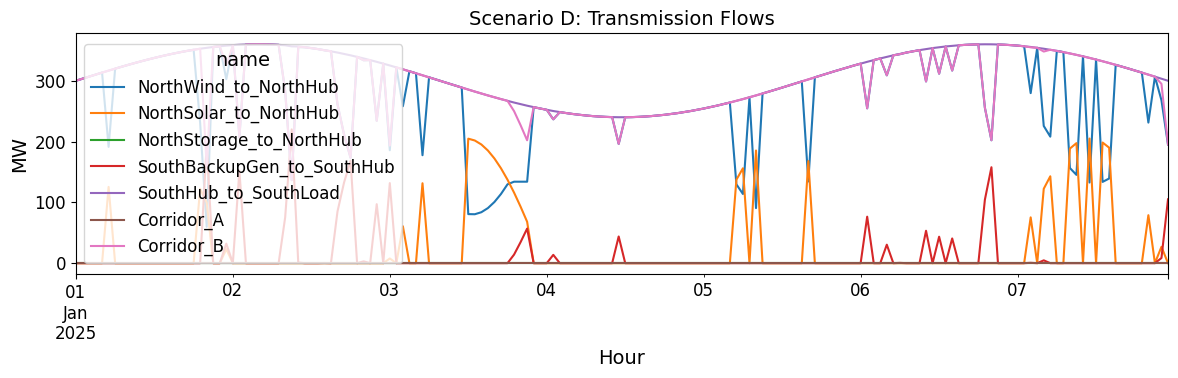

In [50]:
# Plot transmission link power flows
network_d.links_t.p0.plot(title="Scenario D: Transmission Flows", figsize=(12, 4))
plt.ylabel("MW"); plt.xlabel("Hour"); plt.tight_layout(); plt.show()

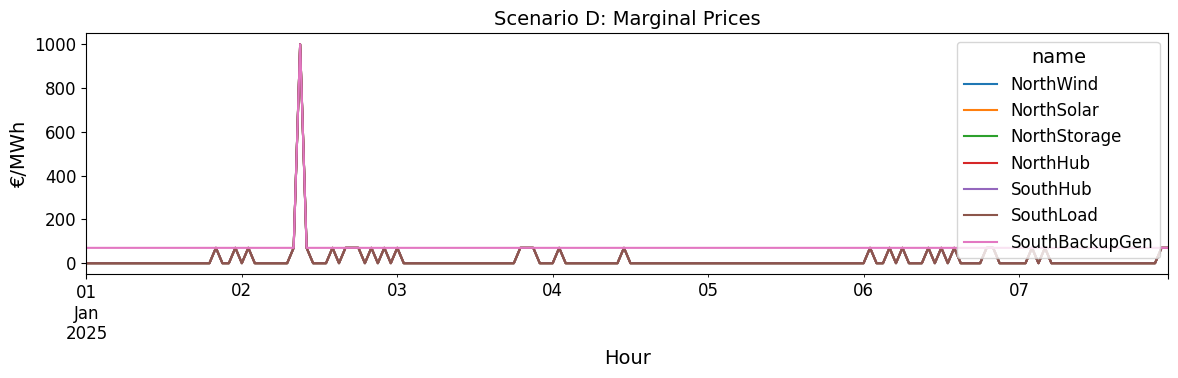

In [51]:
# Plot marginal electricity prices at buses
network_d.buses_t.marginal_price.plot(title="Scenario D: Marginal Prices", figsize=(12, 4))
plt.ylabel("€/MWh"); plt.xlabel("Hour"); plt.tight_layout(); plt.show()

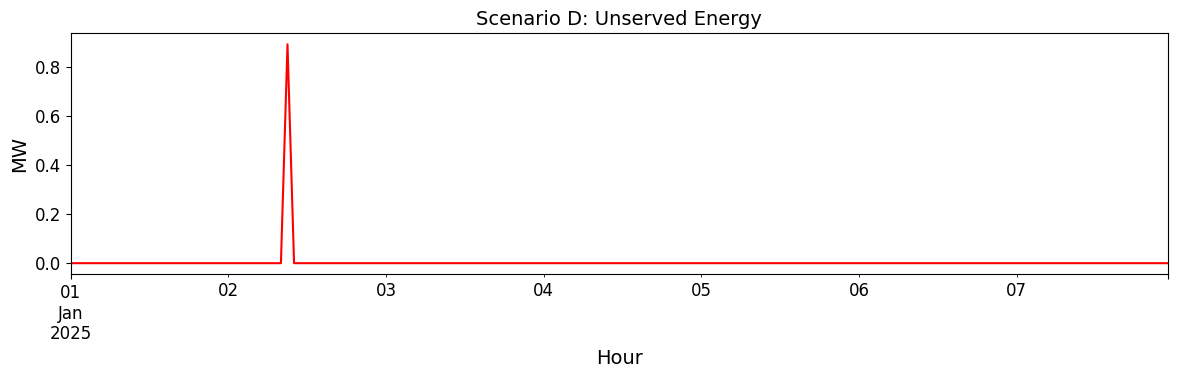

In [52]:
# Plot unserved energy during critical peak demand
network_d.generators_t.p["Unserved"].plot(title="Scenario D: Unserved Energy", figsize=(12, 4), color='red')
plt.ylabel("MW"); plt.xlabel("Hour"); plt.tight_layout(); plt.show()